# Sensitivity of cloud phase to the minimum LWP threshold

How much of the liquid/ice/mixed split is a property of the atmosphere, and
how much is a property of where we put `min_lwp`? The only honest answer is
to vary the threshold and look.

Four figures, all against `min_lwp` over the range set in the load cell:

| Figure | Panels | y axis |
|---|---|---|
| 1 | one per month | share of that month's cell-hours [%] |
| 2 | one per month | hours per month per grid cell |
| 3 | single | share of the whole season's cell-hours [%] |
| 4 | single | hours per season per grid cell |

Figures 1 and 3 are the fraction versions; 2 and 4 are the same curves
multiplied by the length of the month (or the season) in the window.

### Every point comes from one pass over the archive

Every threshold in the sweep is classified **inside the same streaming
pass** as the
nominal run. That matters for two reasons. Cost: at roughly nine minutes to
open the archive, a sweep that reloaded per threshold would take hours and
nobody would run it. Correctness: every curve is built from *identical*
cell-hours, so a difference between two points is the threshold and nothing
else -- not a different subset of files, not a re-read.

### Why the threshold axis is linear

MEASURED over the Barrow strip: the phase split barely moves below about
1 g m-2, and does nearly all of its moving above it. A log axis spent two
thirds of its width, and two thirds of its sample points, on the flat part.
Linear spacing puts the resolution where the answer actually changes.

The cost is that the first step now clears the whole sub-1 g m-2 region in
one jump, so any structure there is unresolved. Pass `sweep_spacing="log"` to get it
back -- that is the better setting for looking at the region where the
threshold is fighting ERA5's own quantisation rather than the cloud.

### Fraction mode only

The sweep exists only under `phase_mode="fraction"`. In absolute mode
liquid-only and mixed-phase carry *separate* LWP floors, so there is no single
"the minimum LWP" to vary -- sweeping them together would change what the
categories mean rather than measure how sensitive they are. The figure
functions raise a `ValueError` saying so if you try.

This notebook drives the same module as the other two, so nothing here is a
second copy of the analysis.

## Setup

In [15]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt

import plot_lwp_histogram_by_surface_class as lwph

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 110

SAVE_DIR = Path("figures/lwp_threshold_sweep")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load the data

`phase_mode="fraction"` is required. The sweep range is set by
`sweep_lwp_min`, `sweep_lwp_max`, `sweep_points` and `sweep_spacing`; the *nominal* `min_lwp`
below still controls the other figures in the module (the histograms and the
monthly bar chart), and appears in the sweep only as one point among the 17.

`min_iwp` is **held fixed** throughout the sweep. Only the liquid floor moves,
which is what makes the curves interpretable: any change is the liquid
threshold acting alone.

In [16]:
A = lwph.prepare(
    region="barrow",
    years=tuple(range(2022, 2026)),   # season START years
    season_start=(10, 1),             # 2 x 3 month grid; use (8, 1) for 2 x 4
    season_end=(3, 31),

    phase_mode="fraction",            # required for the sweep
    liquid_fraction_min=0.90,
    ice_fraction_min=0.90,
    min_lwp=0.1,                      # nominal value, for the other figures
    min_iwp=0.1,                      # held fixed across the sweep

    sweep_lwp_min=0.1,               # g m-2, low end of the x axis
    sweep_lwp_max=25.0,               # g m-2, high end
    sweep_points=30,                  # all classified in one pass
    sweep_spacing="linear",           # "log" resolves the sub-1 region

    min_cloud_fraction=1.0,           # overcast only
    storage="local",
    dpi=350,

    show_ice_only=False,              # ice-only rises when liquid gets zeroed
                                       # out of mixed-phase, not when ice grows;
                                       # off by default so it isn't misread
)

Liquid-bearing cloud hours by LWP and surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 107,856 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 1
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.9 | mixed: the rest | CWP = LWP + IWP above 0.1/0.1 g m-2
               ice only: IWP/CWP >= 0.9
  LWP bins   : linear 0-600 in 24 | log 0.1-1000 in 12

  Seasons found (18), coverage of the 183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001:  99.5%
    2001/2002:  50.3%   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013:  99.5%
    2013/2014:  99.5%
    2014/2015:  99.5%
    2015/2016: 100.0%
    2016/2017:  99.5%
    2017/2018:  93.4%
    2018/2019:  99.5%
    2019/2020: 100.0%
    2020/2021:  99.5%

## 1. Monthly, as a fraction

One panel per month; three lines. y is the share of that month's cell-hours,
the same quantity the monthly bar chart plots -- so reading down a vertical
line at `min_lwp = 0.1` reproduces that chart's bars.

  -> figures/lwp_threshold_sweep/barrow_sweep_monthly_fraction_all_mean2022-2025.png


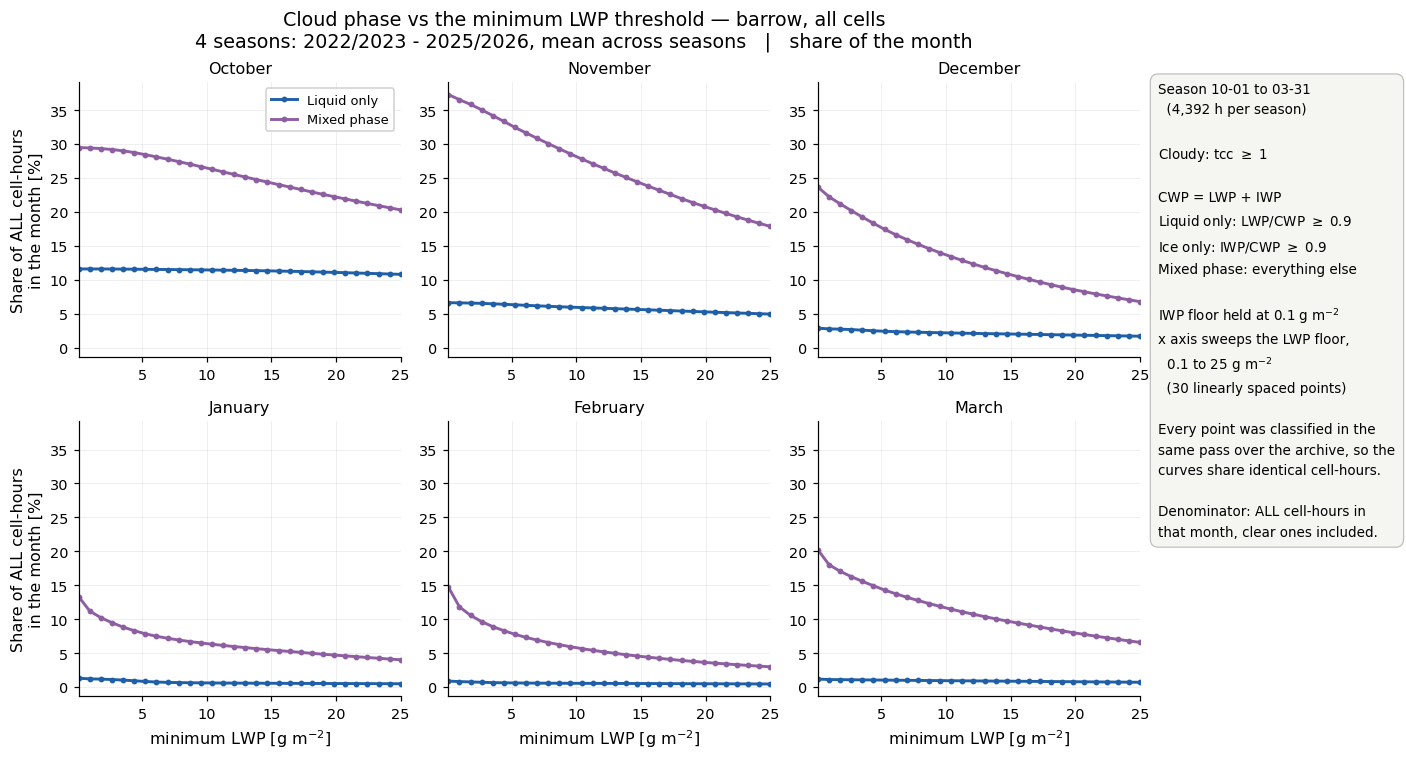

In [17]:
lwph.fig_sweep_monthly(A, out_dir=SAVE_DIR);

## 2. Monthly, as hours

The same curves times each month's own length inside the window (printed in
each panel title), giving average hours per month per grid cell.

  -> figures/lwp_threshold_sweep/barrow_sweep_monthly_hours_all_mean2022-2025.png


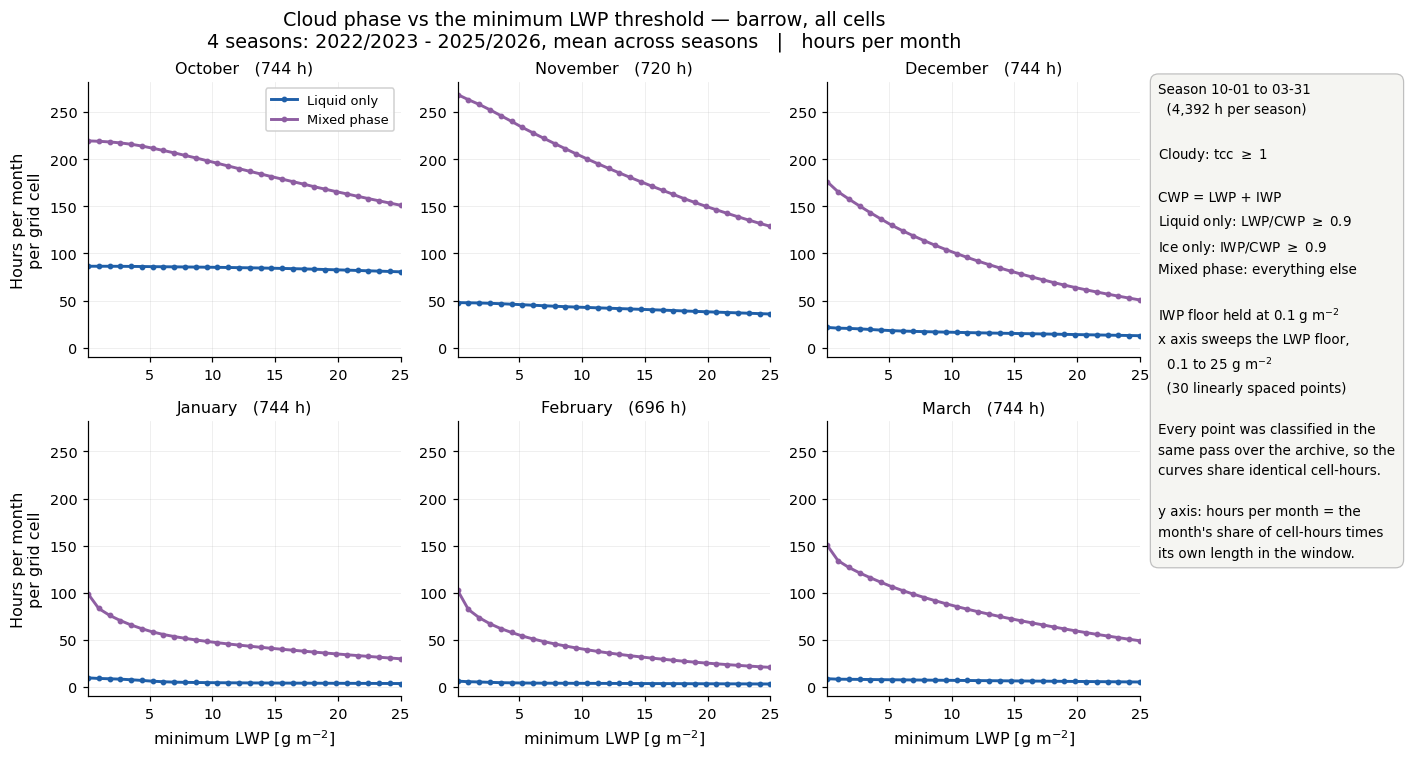

In [18]:
lwph.fig_sweep_monthly(A, as_hours=True, out_dir=SAVE_DIR);

## 3. Whole season, as a fraction

Months pooled **before** dividing, so a 31-day month counts for more than a
28-day one -- which is what "fraction of the season" means. Averaging the six
monthly curves instead would quietly give February December's weight.

Each legend entry carries the value at both ends of the sweep, which is the
number to quote when asked how threshold-sensitive a result is.

  -> figures/lwp_threshold_sweep/barrow_sweep_season_fraction_all_mean2022-2025.png


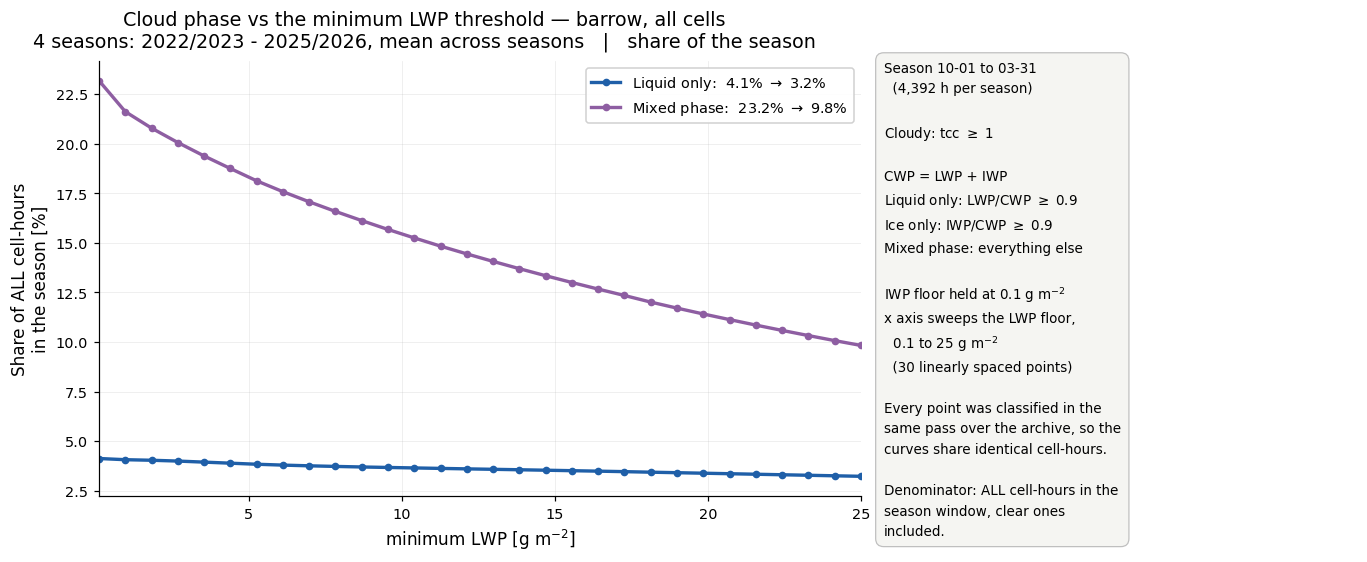

In [19]:
lwph.fig_sweep_season(A, out_dir=SAVE_DIR);

## 4. Whole season, as hours

  -> figures/lwp_threshold_sweep/barrow_sweep_season_hours_all_mean2022-2025.png


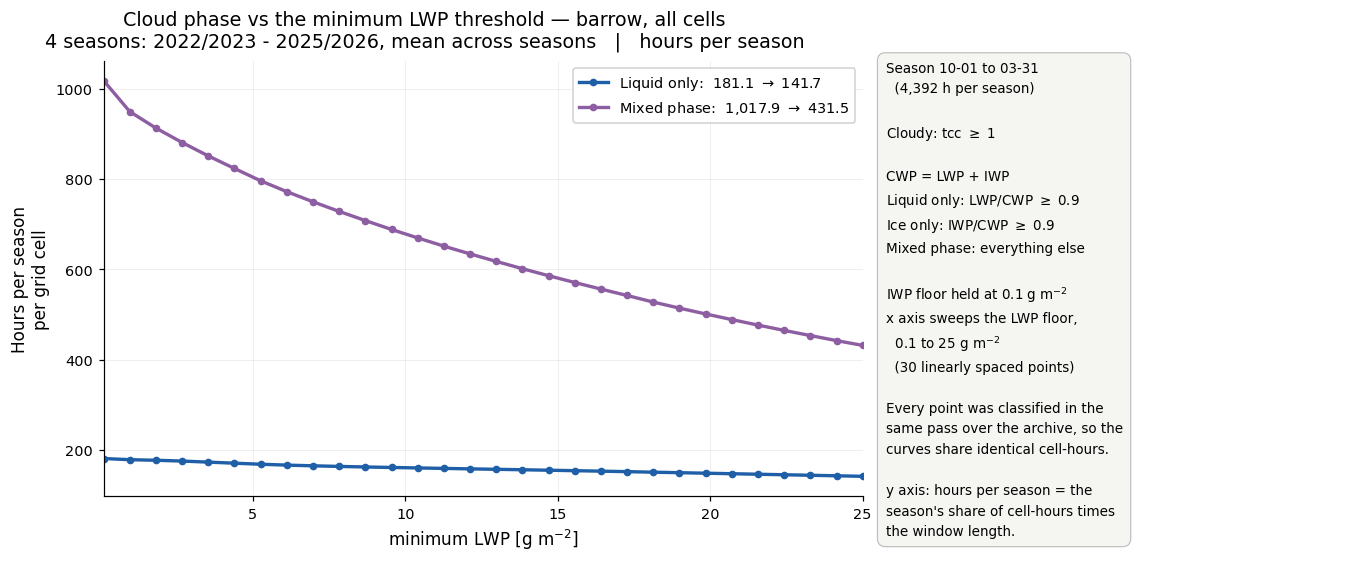

In [20]:
lwph.fig_sweep_season(A, as_hours=True, out_dir=SAVE_DIR);

## By surface class

`surface_class` takes any name from `CLASS_ORDER`, `"arm_site"`, or `"all"`
(the default). No reload -- every class was accumulated in the same pass.

  -> figures/lwp_threshold_sweep/barrow_sweep_season_fraction_open_ocean_mean2022-2025.png
  -> figures/lwp_threshold_sweep/barrow_sweep_season_fraction_sea_ice_mean2022-2025.png
  -> figures/lwp_threshold_sweep/barrow_sweep_season_fraction_arm_site_mean2022-2025.png


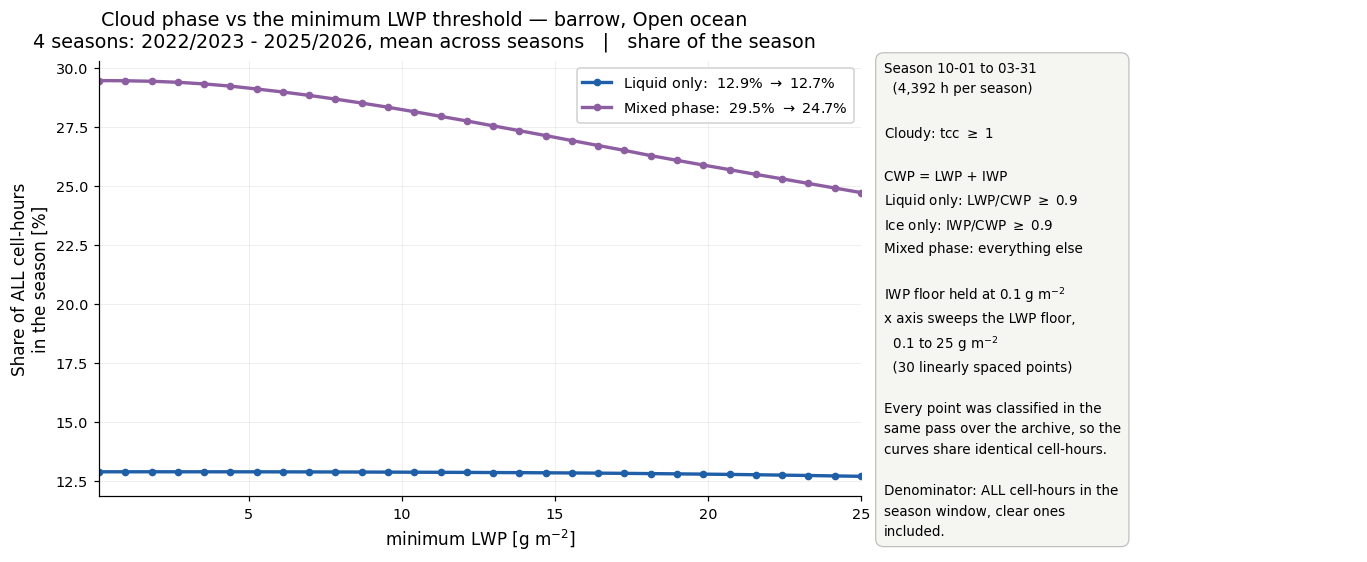

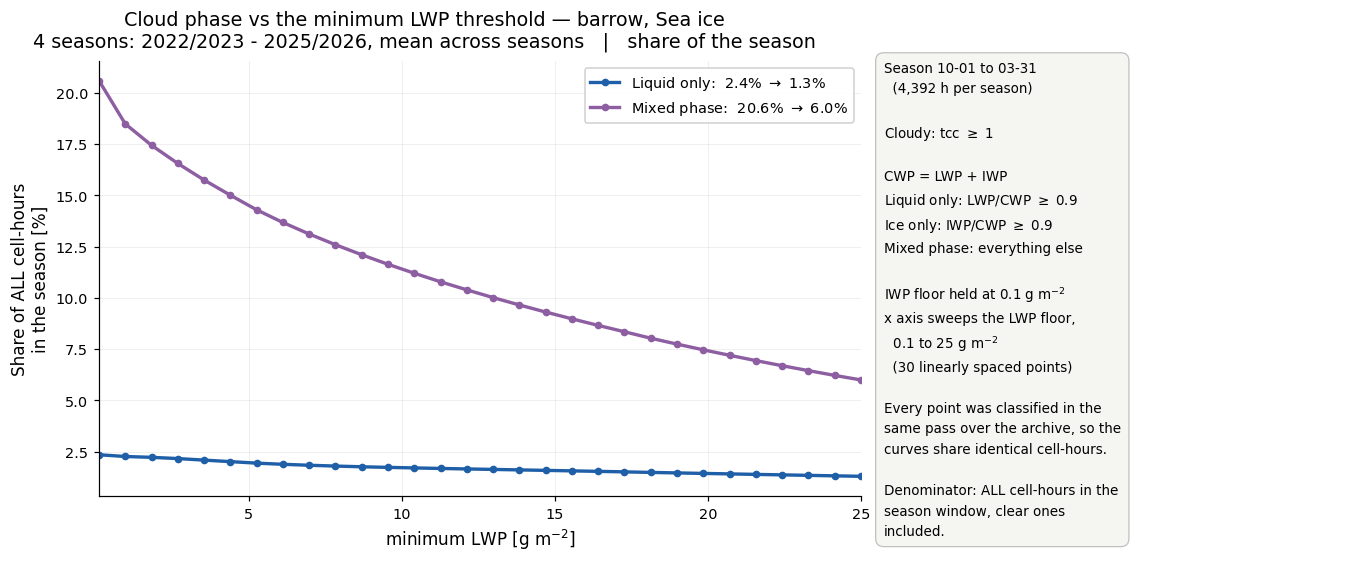

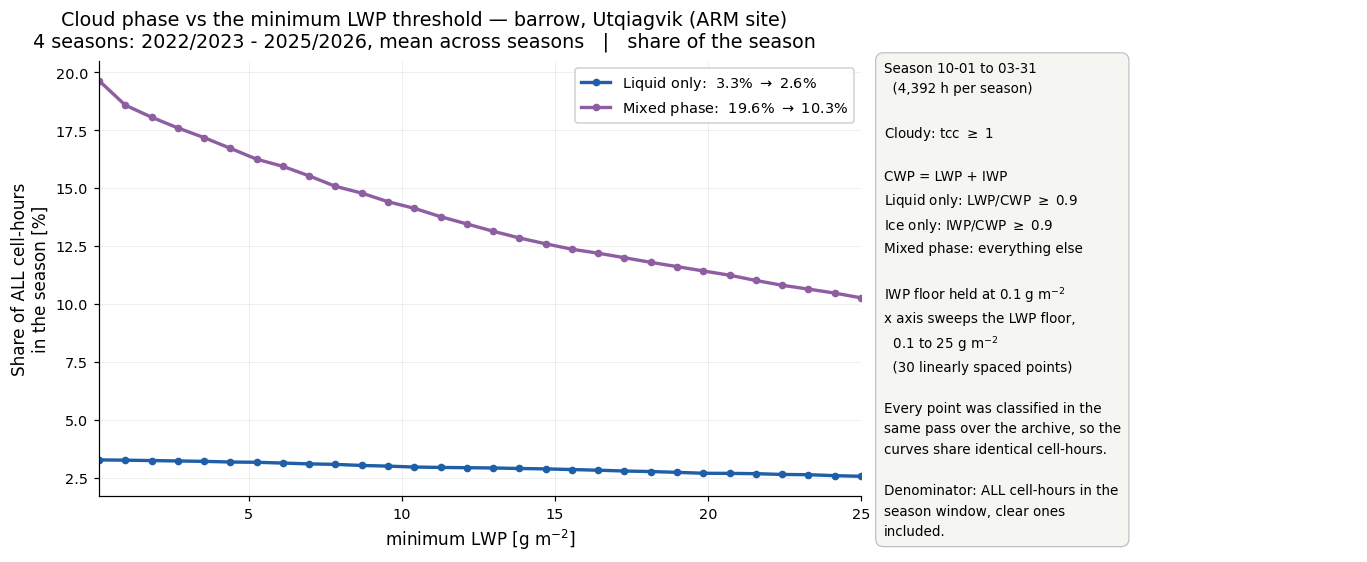

In [21]:
for sc in ("open_ocean", "sea_ice", "arm_site"):
    lwph.fig_sweep_season(A, surface_class=sc, out_dir=SAVE_DIR)

## Reading these figures

**A flat line means the result is threshold-independent** over that range, and
can be quoted without qualification. A steep one means the number is largely a
statement about where the threshold was put.

### The ice-only curve rises. That is not more ice.

The single most confusing thing about these figures. `min_lwp` is **not** a
bar a cloud must clear to be counted -- it is the level below which liquid
is declared **absent**. Raising it therefore pushes clouds *into* ice-only,
not out of it.

Follow one cloud with LWP 10 and IWP 50 g m-2:

| `min_lwp` | effective LWP | CWP | IWP/CWP | called |
|---|---|---|---|---|
| 0.1 | 10 | 60 | 0.833 | mixed |
| 12 | **0** | **50** | **1.000** | **ice only** |

Nothing about the cloud changed. Its liquid stopped counting, so CWP shrank
and the ice share rose past 0.9.

That makes **ice-only an absorbing state**: once `IWP/CWP >= 0.9`, raising
the floor can only zero out more liquid, which can only push the ice share
higher. It is provable, and it shows up exactly in the data. Reclassifying
1.76 M overcast cell-hours from `min_lwp` 0.1 to 25 g m-2:

| from \\ to | liquid | ice | mixed | none |
|---|---|---|---|---|
| liquid | 231,619 | 70,299 | 0 | 3,488 |
| ice | 0 | 384,818 | 0 | 0 |
| mixed | 0 | **510,559** | 562,349 | 0 |
| none | 0 | 0 | 0 | 836 |

**Nothing ever leaves ice-only** -- that row is zero except on the diagonal.
The 580,858-hour gain is 510,559 from mixed plus 70,299 from liquid-only.
Which is why the ice and mixed curves are near mirror images: they are two
views of the same reclassification.

**So read the ice-only curve as a statement about mixed-phase clouds with
marginal liquid, not about ice clouds.** If what you want is "how much
liquid-bearing cloud is there", that is `liquid + mixed`, and it does fall
monotonically as the floor rises, exactly as intuition says it should:
1,378,314 h at 0.1 g m-2 down to 793,968 h at 25.

Two further behaviours are guaranteed by construction, and are worth
checking as a sanity test rather than treating as findings:

- **liquid-only can only fall** as the floor rises, and **ice-only can only
  rise**. Raising the LWP floor zeroes more liquid, which moves scenes toward
  the ice end and never the other way.
- **the three lines plus 'neither' always sum to the overcast share**, which
  does not depend on `min_lwp` at all. The threshold redistributes hours
  between phases; it never creates or destroys cloudy hours.

What is *not* guaranteed, and is the actual content: where the crossover sits,
how sharp it is, and how all of that changes from October to March.

### Changing the sweep

The range and spacing are fixed at load time, so changing either needs a
fresh `prepare()`. Note `sweep_lwp_min=0` is legal under linear spacing and
means "any non-zero liquid counts"; log spacing cannot start there.

```python
# a wider linear range
A_wide = lwph.prepare(region="barrow", years=(2019, 2020),
                      phase_mode="fraction",
                      sweep_lwp_min=0.0, sweep_lwp_max=100.0,
                      sweep_points=26)

# log spacing, to resolve the sub-1 g m-2 region the linear sweep skips
A_log = lwph.prepare(region="barrow", years=(2019, 2020),
                     phase_mode="fraction", sweep_spacing="log",
                     sweep_lwp_min=0.01, sweep_lwp_max=20.0,
                     sweep_points=25)
lwph.fig_sweep_season(A_log)
```